In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
aqi_df = pd.read_csv("data/daily_aqi_by_county_2025.csv")

aqi_df_2 = aqi_df.drop(["State Code", "County Code", "Number of Sites Reporting"], axis=1)
aqi_df_3 = aqi_df_2.rename(columns={"county Name" : "County Name",
                                    "Date" : "Date Local",
                                  "Category" : "AQI Category",
                                  "Defining Parameter" : "AQI Defining Parameter",
                                  "Defining Site" : "AQI Defining Site"})

aqi_df_3.info()
aqi_df_3.head(20)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105869 entries, 0 to 105868
Data columns (total 7 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   State Name              105869 non-null  object
 1   County Name             105869 non-null  object
 2   Date Local              105869 non-null  object
 3   AQI                     105869 non-null  int64 
 4   AQI Category            105869 non-null  object
 5   AQI Defining Parameter  105869 non-null  object
 6   AQI Defining Site       105869 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.7+ MB


,State Name,County Name,Date Local,AQI,AQI Category,AQI Defining Parameter,AQI Defining Site
0,Alabama,Baldwin,2025-01-01,20,Good,PM2.5,01-003-0010
1,Alabama,Baldwin,2025-01-02,37,Good,PM2.5,01-003-0010
2,Alabama,Baldwin,2025-01-03,52,Moderate,PM2.5,01-003-0010
3,Alabama,Baldwin,2025-01-04,31,Good,PM2.5,01-003-0010
4,Alabama,Baldwin,2025-01-05,31,Good,PM2.5,01-003-0010
5,Alabama,Baldwin,2025-01-06,14,Good,PM2.5,01-003-0010
6,Alabama,Baldwin,2025-01-07,14,Good,PM2.5,01-003-0010
7,Alabama,Baldwin,2025-01-08,30,Good,PM2.5,01-003-0010
8,Alabama,Baldwin,2025-01-09,40,Good,PM2.5,01-003-0010
9,Alabama,Baldwin,2025-01-10,34,Good,PM2.5,01-003-0010


In [3]:
temp_df = pd.read_csv("data/daily_TEMP_2025.csv")

temp_df.info()
temp_df.head(20)

temp_df_2 = temp_df.drop(["State Code", "County Code", "Parameter Code", 
                          "POC", "Datum", "Parameter Name", "Pollutant Standard",
                          "Event Type", "AQI", "City Name", "CBSA Name"], axis=1)
temp_df_3 = temp_df_2.rename(columns={"Sample Duration" : "Temp Sample Duration", 
                                          "Units of Measure" : "Temp Units of Measure",
                                          "Observation Count" : "Temp Observation Count",
                                          "Observation Percent" : "Temp Observation Percent",
                                          "Arithmetic Mean" : "Temp Arithmetic Mean",
                                          "1st Max Value" : "Temp 1st Max Value",
                                          "1st Max Hour" : "Temp 1st Max Hour",
                                          "Method Code" : "Temp Method Code",
                                          "Method Name" : "Temp Method Name",
                                          "Date of Last Change" : "Temp Date of Last Change"})
new_temp_df_col_order = ["State Name", "County Name",
                         "Local Site Name", "Address",
                         "Site Num", "Longitude",
                         "Latitude", "Date Local",
                         "Temp Units of Measure", "Temp Observation Count",
                         "Temp Observation Percent", "Temp Arithmetic Mean",
                         "Temp 1st Max Value", "Temp 1st Max Hour",
                         "Temp Method Code", "Temp Method Name"]

temp_df_clean = temp_df_3[new_temp_df_col_order]

temp_df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82755 entries, 0 to 82754
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   State Code           82755 non-null  int64  
 1   County Code          82755 non-null  int64  
 2   Site Num             82755 non-null  int64  
 3   Parameter Code       82755 non-null  int64  
 4   POC                  82755 non-null  int64  
 5   Latitude             82755 non-null  float64
 6   Longitude            82755 non-null  float64
 7   Datum                82755 non-null  object 
 8   Parameter Name       82755 non-null  object 
 9   Sample Duration      82755 non-null  object 
 10  Pollutant Standard   0 non-null      float64
 11  Date Local           82755 non-null  object 
 12  Units of Measure     82755 non-null  object 
 13  Event Type           0 non-null      float64
 14  Observation Count    82755 non-null  int64  
 15  Observation Percent  82755 non-null 

In [4]:
wind_df = pd.read_csv("data/daily_WIND_2025.csv")

wind_df.info()
wind_df.head(20)

wind_df_2 = wind_df.drop(["State Code", "County Code", "Parameter Code", 
                          "POC", "Datum", "Parameter Name", "Pollutant Standard",
                          "Event Type", "AQI", "City Name", "CBSA Name"], axis=1)
wind_df_3 = wind_df_2.rename(columns={"Sample Duration" : "Temp Sample Duration", 
                                          "Units of Measure" : "Wind Units of Measure",
                                          "Observation Count" : "Wind Observation Count",
                                          "Observation Percent" : "Wind Observation Percent",
                                          "Arithmetic Mean" : "Wind Arithmetic Mean",
                                          "1st Max Value" : "Wind 1st Max Value",
                                          "1st Max Hour" : "Wind 1st Max Hour",
                                          "Method Code" : "Wind Method Code",
                                          "Method Name" : "Wind Method Name",
                                          "Date of Last Change" : "Wind Date of Last Change"})
new_wind_df_col_order = ["State Name", "County Name",
                         "Local Site Name", "Address",
                         "Site Num", "Longitude",
                         "Latitude", "Date Local",
                         "Wind Units of Measure", "Wind Observation Count",
                         "Wind Observation Percent", "Wind Arithmetic Mean",
                         "Wind 1st Max Value", "Wind 1st Max Hour",
                         "Wind Method Code", "Wind Method Name"]

wind_df_clean = wind_df_3[new_wind_df_col_order]

wind_df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129451 entries, 0 to 129450
Data columns (total 29 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   State Code           129451 non-null  int64  
 1   County Code          129451 non-null  int64  
 2   Site Num             129451 non-null  int64  
 3   Parameter Code       129451 non-null  int64  
 4   POC                  129451 non-null  int64  
 5   Latitude             129451 non-null  float64
 6   Longitude            129451 non-null  float64
 7   Datum                129451 non-null  object 
 8   Parameter Name       129451 non-null  object 
 9   Sample Duration      129451 non-null  object 
 10  Pollutant Standard   0 non-null       float64
 11  Date Local           129451 non-null  object 
 12  Units of Measure     129451 non-null  object 
 13  Event Type           0 non-null       float64
 14  Observation Count    129451 non-null  int64  
 15  Observation Perce

In [12]:
first_merge = pd.merge(temp_df_clean, wind_df_clean, on = ["State Name", "County Name", 
                                             "Local Site Name", "Address", 
                                             "Site Num", "Longitude", 
                                             "Latitude", "Date Local"])

merged_df = pd.merge(first_merge, aqi_df_3, on = ["State Name", "County Name", "Date Local"])

merged_df.info()
merged_df.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111576 entries, 0 to 111575
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   State Name                111576 non-null  object 
 1   County Name               111576 non-null  object 
 2   Local Site Name           108760 non-null  object 
 3   Address                   111576 non-null  object 
 4   Site Num                  111576 non-null  int64  
 5   Longitude                 111576 non-null  float64
 6   Latitude                  111576 non-null  float64
 7   Date Local                111576 non-null  object 
 8   Temp Units of Measure     111576 non-null  object 
 9   Temp Observation Count    111576 non-null  int64  
 10  Temp Observation Percent  111576 non-null  float64
 11  Temp Arithmetic Mean      111576 non-null  float64
 12  Temp 1st Max Value        111576 non-null  float64
 13  Temp 1st Max Hour         111576 non-null  i

,State Name,County Name,Local Site Name,Address,Site Num,Longitude,Latitude,Date Local,Temp Units of Measure,Temp Observation Count,...,Wind Observation Percent,Wind Arithmetic Mean,Wind 1st Max Value,Wind 1st Max Hour,Wind Method Code,Wind Method Name,AQI,AQI Category,AQI Defining Parameter,AQI Defining Site
0,Alaska,Denali,Denali NP,DENALI NATIONAL PARK,3,-148.9676,63.7232,2025-01-01,Degrees Fahrenheit,24,...,100.0,0.408333,0.8,1,20,INSTRUMENTAL - VECTOR SUMMATION,40,Good,Ozone,02-068-0003
1,Alaska,Denali,Denali NP,DENALI NATIONAL PARK,3,-148.9676,63.7232,2025-01-01,Degrees Fahrenheit,24,...,100.0,239.083333,358.0,9,20,INSTRUMENTAL - VECTOR SUMMATION,40,Good,Ozone,02-068-0003
2,Alaska,Denali,Denali NP,DENALI NATIONAL PARK,3,-148.9676,63.7232,2025-01-02,Degrees Fahrenheit,24,...,100.0,0.433333,1.0,6,20,INSTRUMENTAL - VECTOR SUMMATION,36,Good,Ozone,02-068-0003
3,Alaska,Denali,Denali NP,DENALI NATIONAL PARK,3,-148.9676,63.7232,2025-01-02,Degrees Fahrenheit,24,...,100.0,252.416667,359.0,20,20,INSTRUMENTAL - VECTOR SUMMATION,36,Good,Ozone,02-068-0003
4,Alaska,Denali,Denali NP,DENALI NATIONAL PARK,3,-148.9676,63.7232,2025-01-03,Degrees Fahrenheit,24,...,100.0,0.375000,1.0,8,20,INSTRUMENTAL - VECTOR SUMMATION,38,Good,Ozone,02-068-0003
5,Alaska,Denali,Denali NP,DENALI NATIONAL PARK,3,-148.9676,63.7232,2025-01-03,Degrees Fahrenheit,24,...,100.0,250.208333,354.0,19,20,INSTRUMENTAL - VECTOR SUMMATION,38,Good,Ozone,02-068-0003
6,Alaska,Denali,Denali NP,DENALI NATIONAL PARK,3,-148.9676,63.7232,2025-01-04,Degrees Fahrenheit,24,...,100.0,0.583333,1.0,4,20,INSTRUMENTAL - VECTOR SUMMATION,41,Good,Ozone,02-068-0003
7,Alaska,Denali,Denali NP,DENALI NATIONAL PARK,3,-148.9676,63.7232,2025-01-04,Degrees Fahrenheit,24,...,100.0,273.041667,358.0,1,20,INSTRUMENTAL - VECTOR SUMMATION,41,Good,Ozone,02-068-0003
8,Alaska,Denali,Denali NP,DENALI NATIONAL PARK,3,-148.9676,63.7232,2025-01-05,Degrees Fahrenheit,24,...,100.0,1.204167,5.8,16,20,INSTRUMENTAL - VECTOR SUMMATION,41,Good,Ozone,02-068-0003
9,Alaska,Denali,Denali NP,DENALI NATIONAL PARK,3,-148.9676,63.7232,2025-01-05,Degrees Fahrenheit,24,...,100.0,154.958333,360.0,0,20,INSTRUMENTAL - VECTOR SUMMATION,41,Good,Ozone,02-068-0003


In [26]:
grouped_temp = merged_df[["State Name", "Temp Arithmetic Mean"]].groupby(["State Name"]).mean()
grouped_wind = merged_df[["State Name", "Wind Arithmetic Mean"]].groupby(["State Name"]).mean()
grouped_aqi = merged_df[["State Name", "AQI"]].groupby(["State Name"]).mean()

In [33]:
states = list(set(merged_df["State Name"].tolist()))
temps = grouped_temp["Temp Arithmetic Mean"].tolist()
winds = grouped_wind["Wind Arithmetic Mean"].tolist()
aqis = grouped_aqi["AQI"].tolist()

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46],
 [Text(0, 0, 'Illinois'),
  Text(1, 0, 'Louisiana'),
  Text(2, 0, 'Kansas'),
  Text(3, 0, 'North Carolina'),
  Text(4, 0, 'Indiana'),
  Text(5, 0, 'District Of Columbia'),
  Text(6, 0, 'Minnesota'),
  Text(7, 0, 'New Jersey'),
  Text(8, 0, 'South Carolina'),
  Text(9, 0, 'Nebraska'),
  Text(10, 0, 'Maine'),
  Text(11, 0, 'Utah'),
  Text(12, 0, 'Maryland'),
  Text(13, 0, 'Wyoming'),
  Text(14, 0, 'Virginia'),
  Text(15, 0, 'Rhode Island'),
  Text(16, 0, 'West Virginia'),
  Text(17, 0, 'Kentucky'),
  Text(18, 0, 'Idaho'),
  Text(19, 0, 'New Mexico'),
  Text(20, 0, 'South Dakota'),
  Text(21, 0, 'Montana'),
  Text(22, 0, 'New Hampshire'),
  Text(23, 0, 'Missouri'),
  Text(24, 0, 'North Dakota'),
  Text(25, 0, 'Pennsylvan

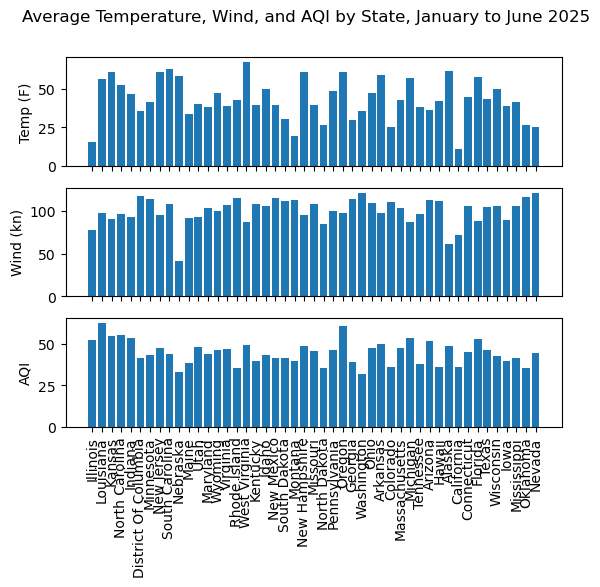

In [43]:
fig, axs = plt.subplots(3, sharex = True)
fig.suptitle("Average Temperature, Wind, and AQI by State, January to June 2025")
axs[0].bar(states, temps)
axs[1].bar(states, winds)
axs[2].bar(states, aqis)

axs[0].set_ylabel("Temp (F)")
axs[1].set_ylabel("Wind (kn)")
axs[2].set_ylabel("AQI")

plt.xticks(rotation = 90)